**Laptop Battery Health & Overheating Prediction – EDA, Feature Engineering, and Classification**

### Table of Contents ###

1. **Introduction**

   * Notebook overview
   * Objectives

3. **Dataset Overview**

   * Load dataset
   * View sample data
   * Check data types and missing values

4. **Exploratory Data Analysis (EDA)**

   * Numerical feature analysis

     * Histograms & KDE plots
     * Boxplots & Violin plots
   * Categorical feature analysis

     * Count plots
     * Pie charts
   * Correlation analysis

     * Heatmap
     * Pairplots
   * High-impact visualizations

     * Battery health vs daily usage hours
     * Charging cycles vs battery age
     * Overheating issues vs performance rating

5. **Data Preprocessing & Feature Engineering**

   * Handle missing values (if any)
   * Encode categorical variables
   * Feature scaling
   * Target and feature split

6. **Model Building & Evaluation**

   * Train-test split
   * Classification models

     * Random Forest Classifier
     * Decision Tree Classifier
     * Logistic Regression
     * Support Vector Classifier
   * Evaluate models

     * Accuracy
     * Classification report
     * Confusion matrix
   * Feature importance analysis

7. **Conclusion & Insights**

   * Key findings from EDA and feature importance
   * Recommendations to prevent overheating

---




In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("/kaggle/input/laptop-battery-health-and-usage-dataset/laptop_battery_health_usage.csv")
df.head()

,device_id,brand,model_year,os,usage_type,daily_usage_hours,charging_cycles,avg_charge_limit_percent,battery_health_percent,battery_age_months,overheating_issues,performance_rating
0,LB001,HP,2021,Windows,Office,6,420,90,86,36,No,4
1,LB002,Dell,2020,Windows,Programming,8,610,100,78,48,Yes,3
2,LB003,Apple,2022,macOS,Creative,7,310,85,92,24,No,5
3,LB004,Lenovo,2019,Windows,Student,5,700,100,70,60,Yes,3
4,LB005,Asus,2021,Windows,Gaming,9,820,100,65,40,Yes,2


In [3]:
# Shape and info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary statistics for numerical columns:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Dataset Shape: (50, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   device_id                 50 non-null     object
 1   brand                     50 non-null     object
 2   model_year                50 non-null     int64 
 3   os                        50 non-null     object
 4   usage_type                50 non-null     object
 5   daily_usage_hours         50 non-null     int64 
 6   charging_cycles           50 non-null     int64 
 7   avg_charge_limit_percent  50 non-null     int64 
 8   battery_health_percent    50 non-null     int64 
 9   battery_age_months        50 non-null     int64 
 10  overheating_issues        50 non-null     object
 11  performance_rating        50 non-null     int64 
dtypes: int64(7), object(5)
memory usage: 4.8+ KB
None

Summary statistics for numerical columns:
    

In [4]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['device_id', 'brand', 'os', 'usage_type', 'overheating_issues']
Numerical columns: ['model_year', 'daily_usage_hours', 'charging_cycles', 'avg_charge_limit_percent', 'battery_health_percent', 'battery_age_months', 'performance_rating']


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


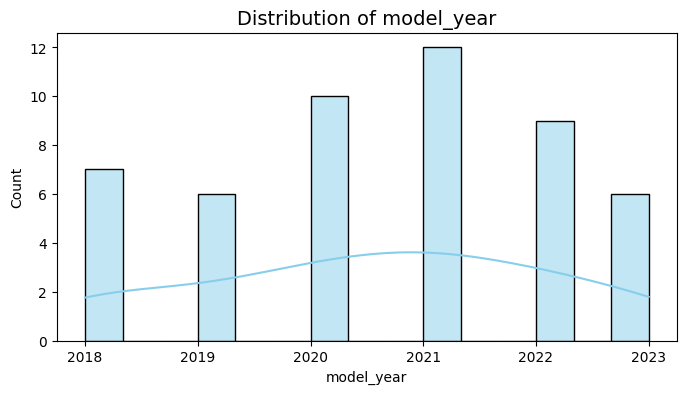

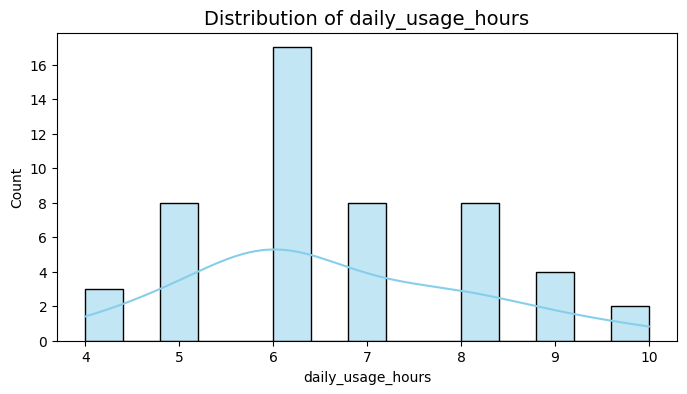

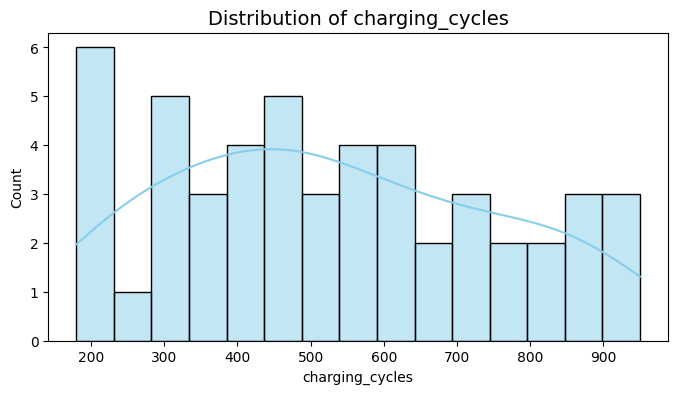

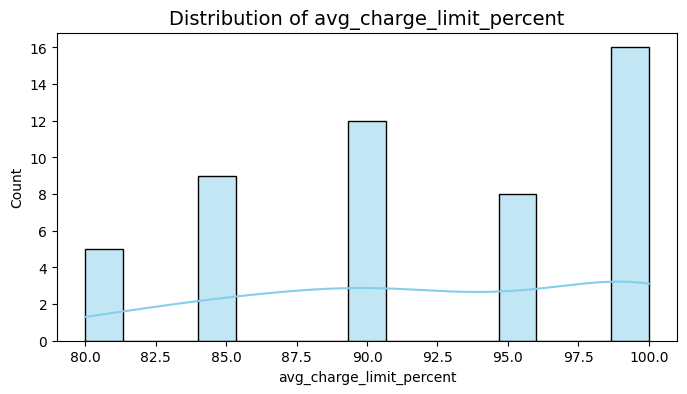

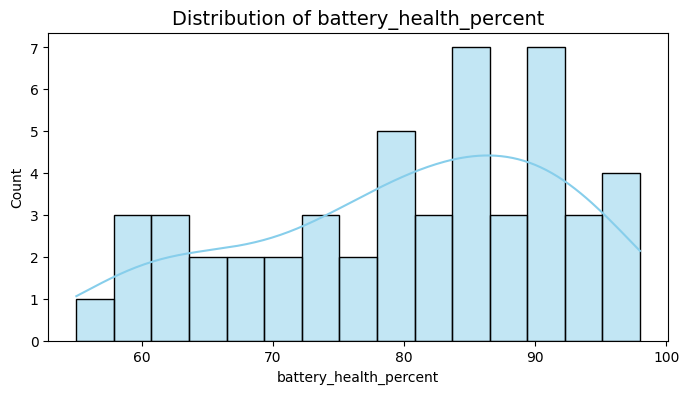

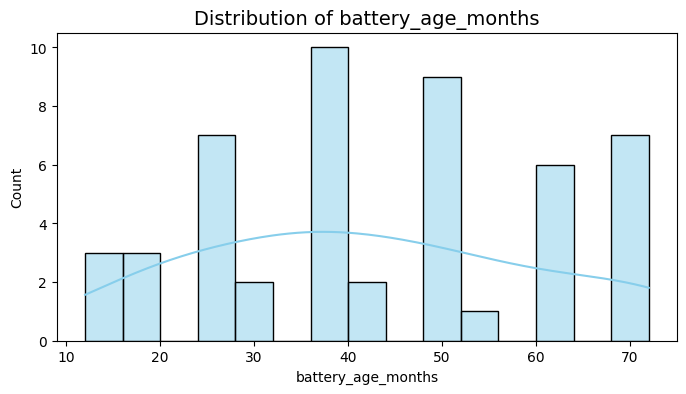

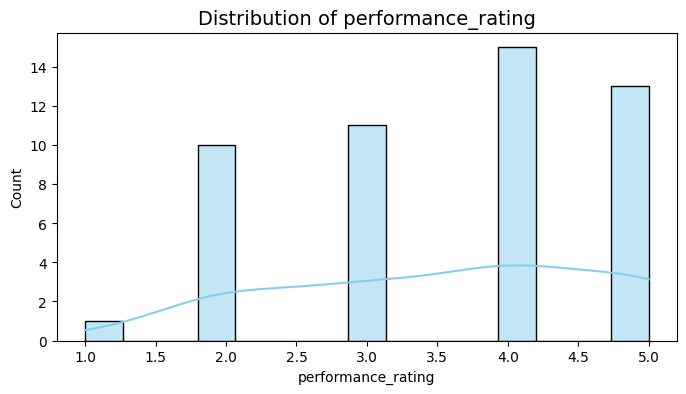

In [6]:
# Histograms + KDE
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=15, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.show()




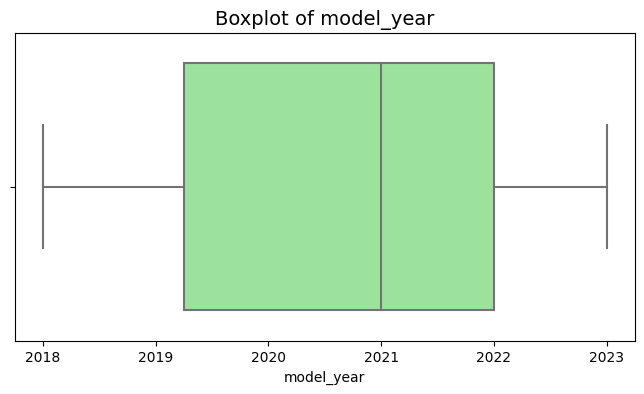

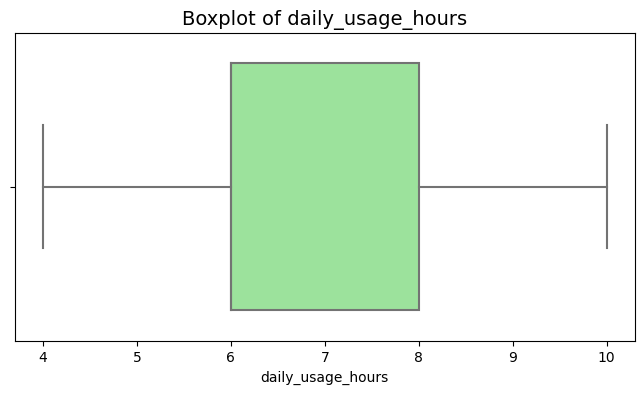

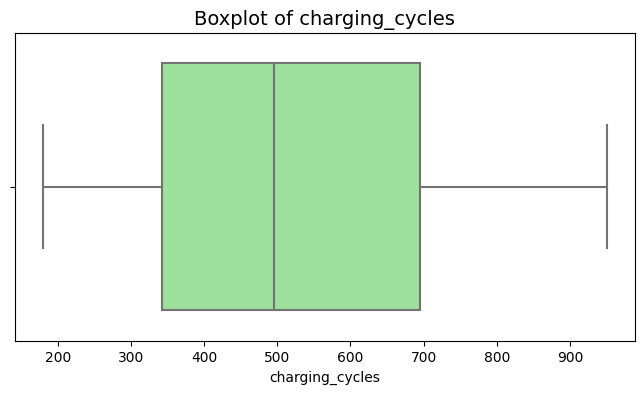

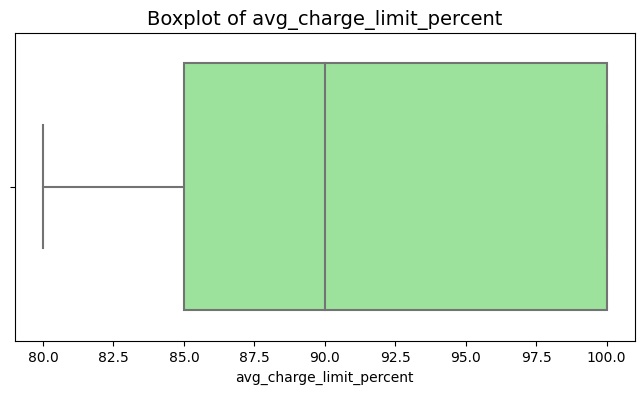

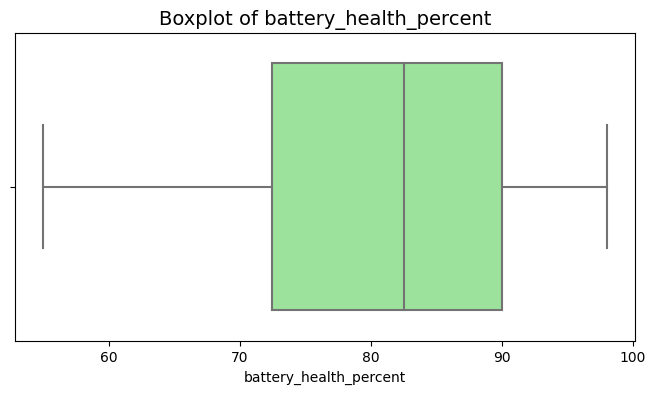

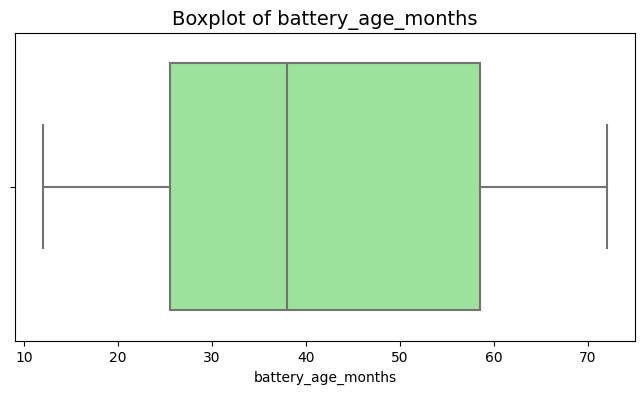

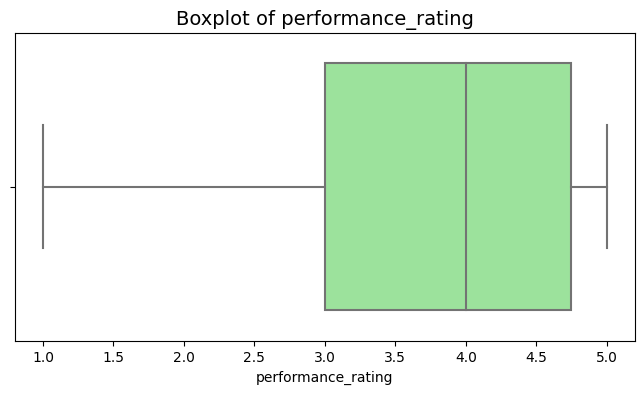

In [7]:
# Boxplots
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.show()

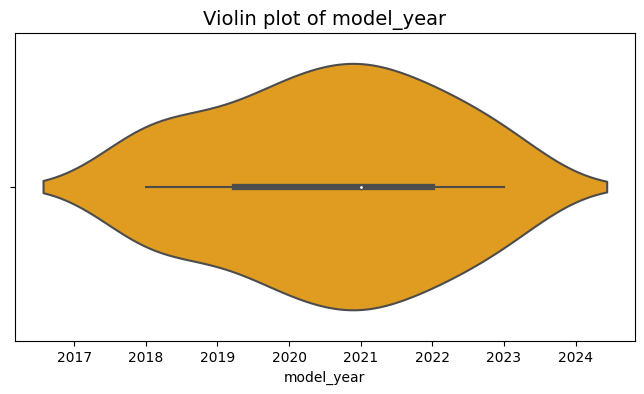

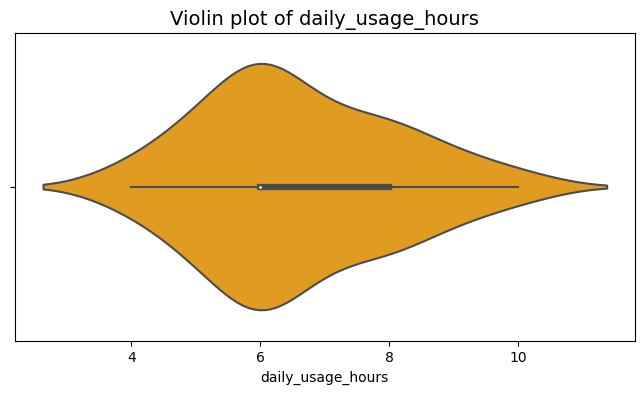

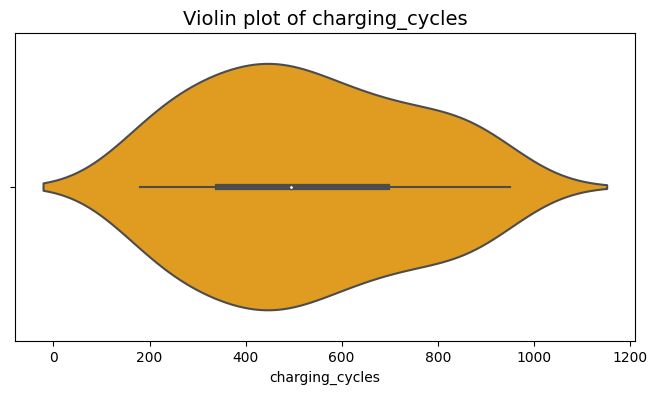

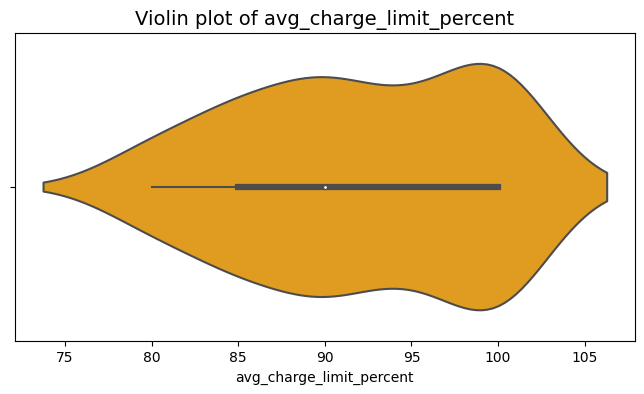

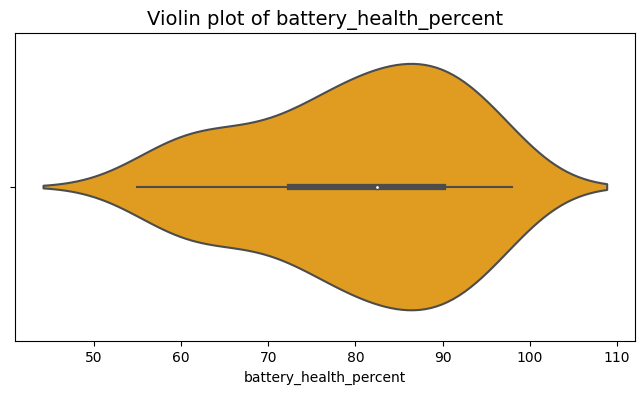

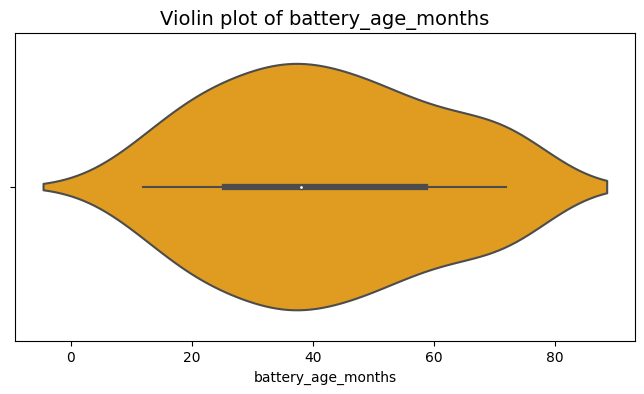

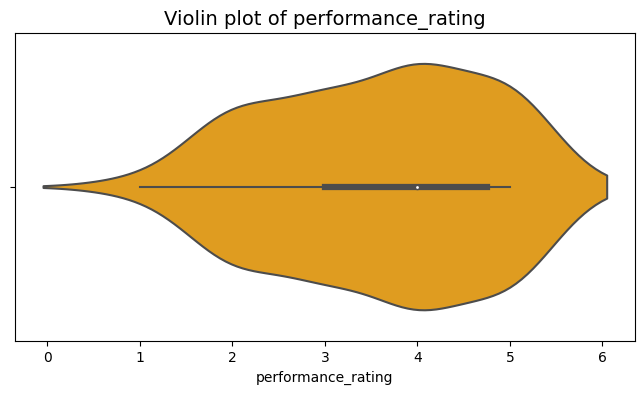

In [8]:
# Violin plots
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.violinplot(x=df[col], color='orange')
    plt.title(f'Violin plot of {col}', fontsize=14)
    plt.show()

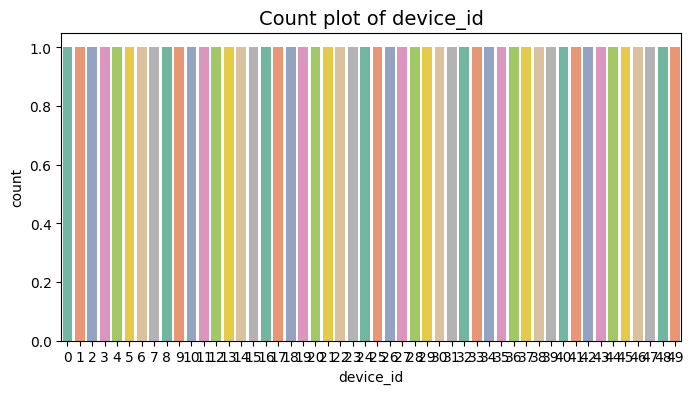

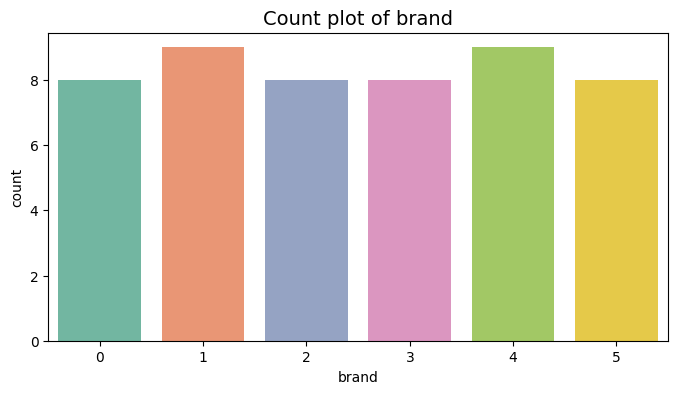

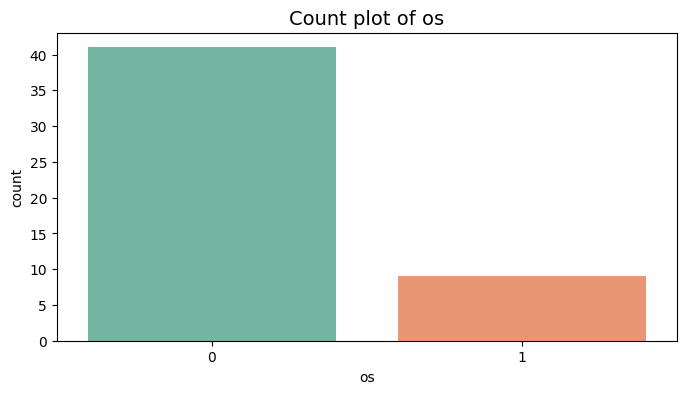

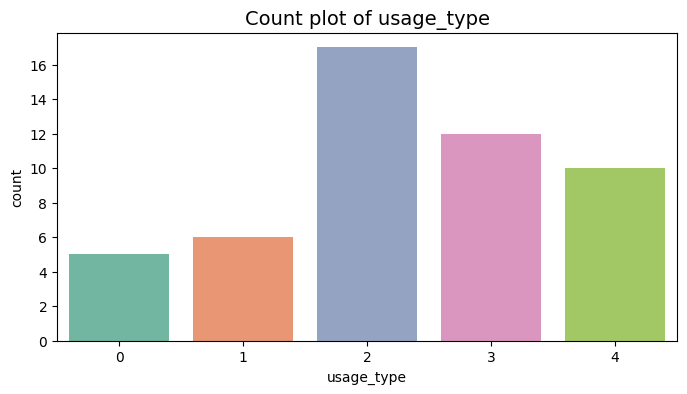

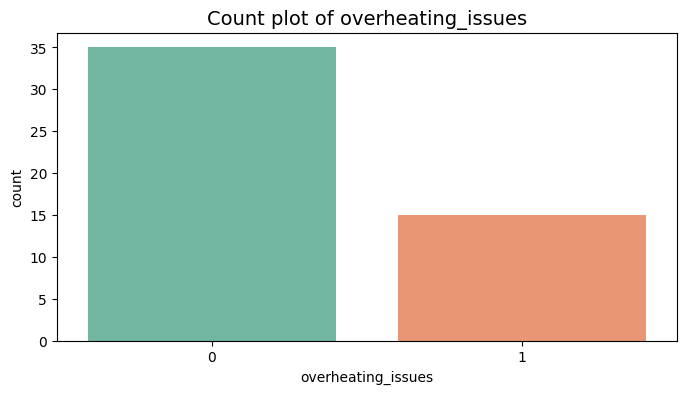

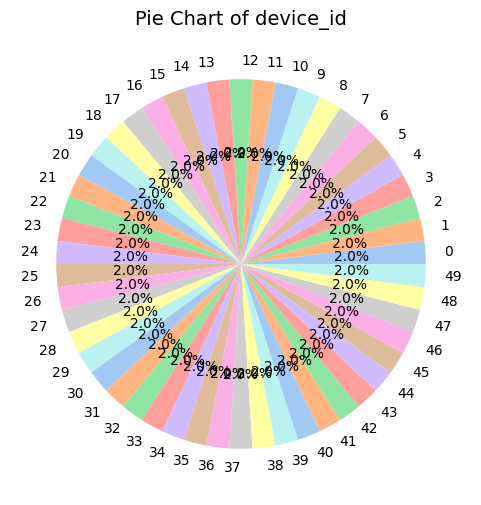

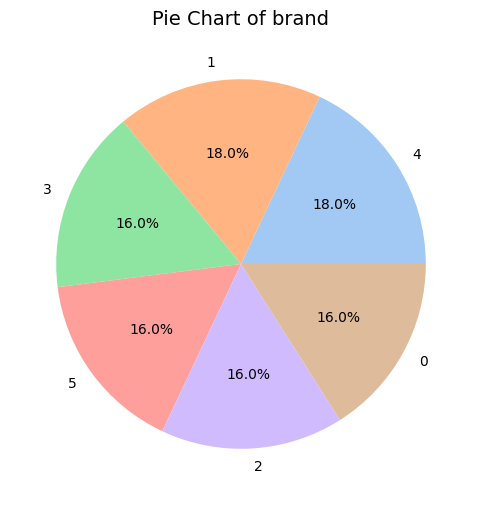

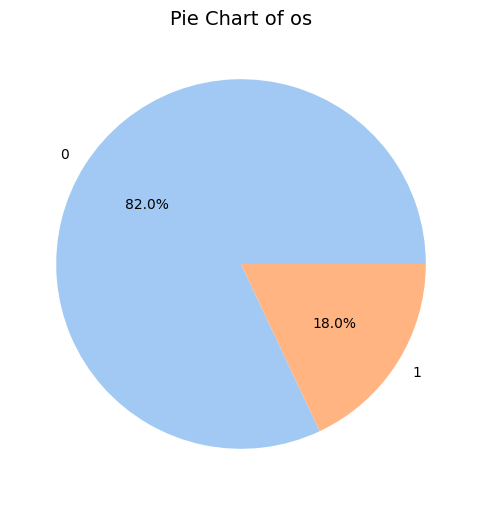

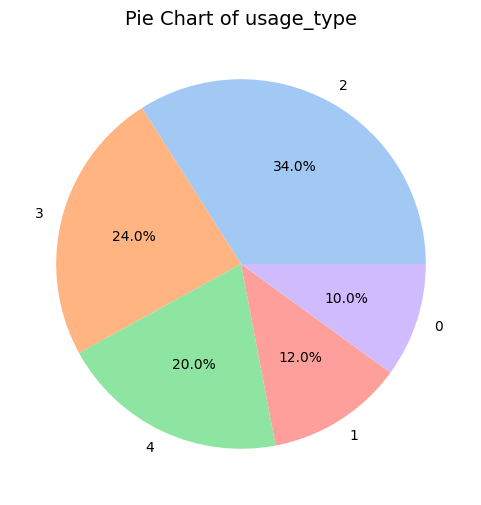

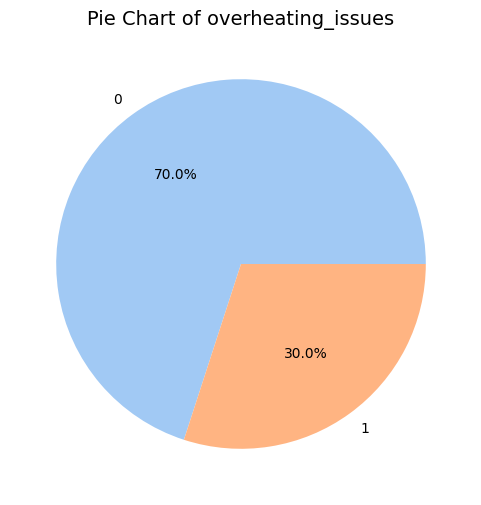

In [9]:
# Count plots
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], palette='Set2')
    plt.title(f'Count plot of {col}', fontsize=14)
    plt.show()

# Pie charts
for col in categorical_cols:
    plt.figure(figsize=(6,6))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title(f'Pie Chart of {col}', fontsize=14)
    plt.ylabel('')
    plt.show()


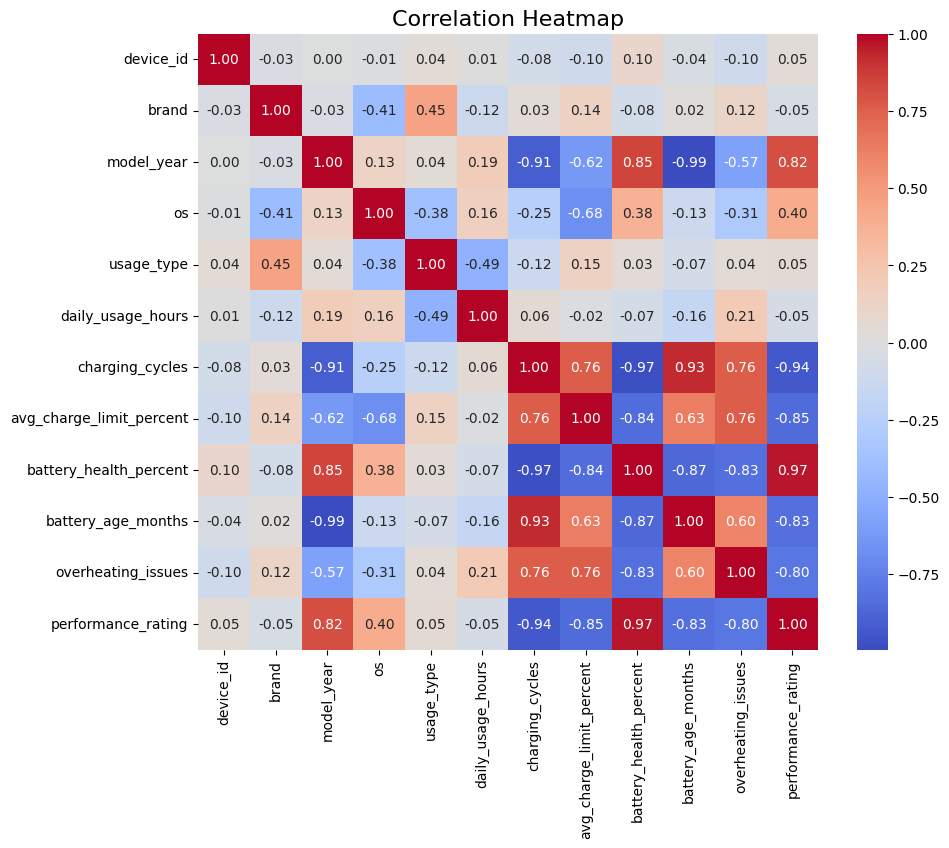

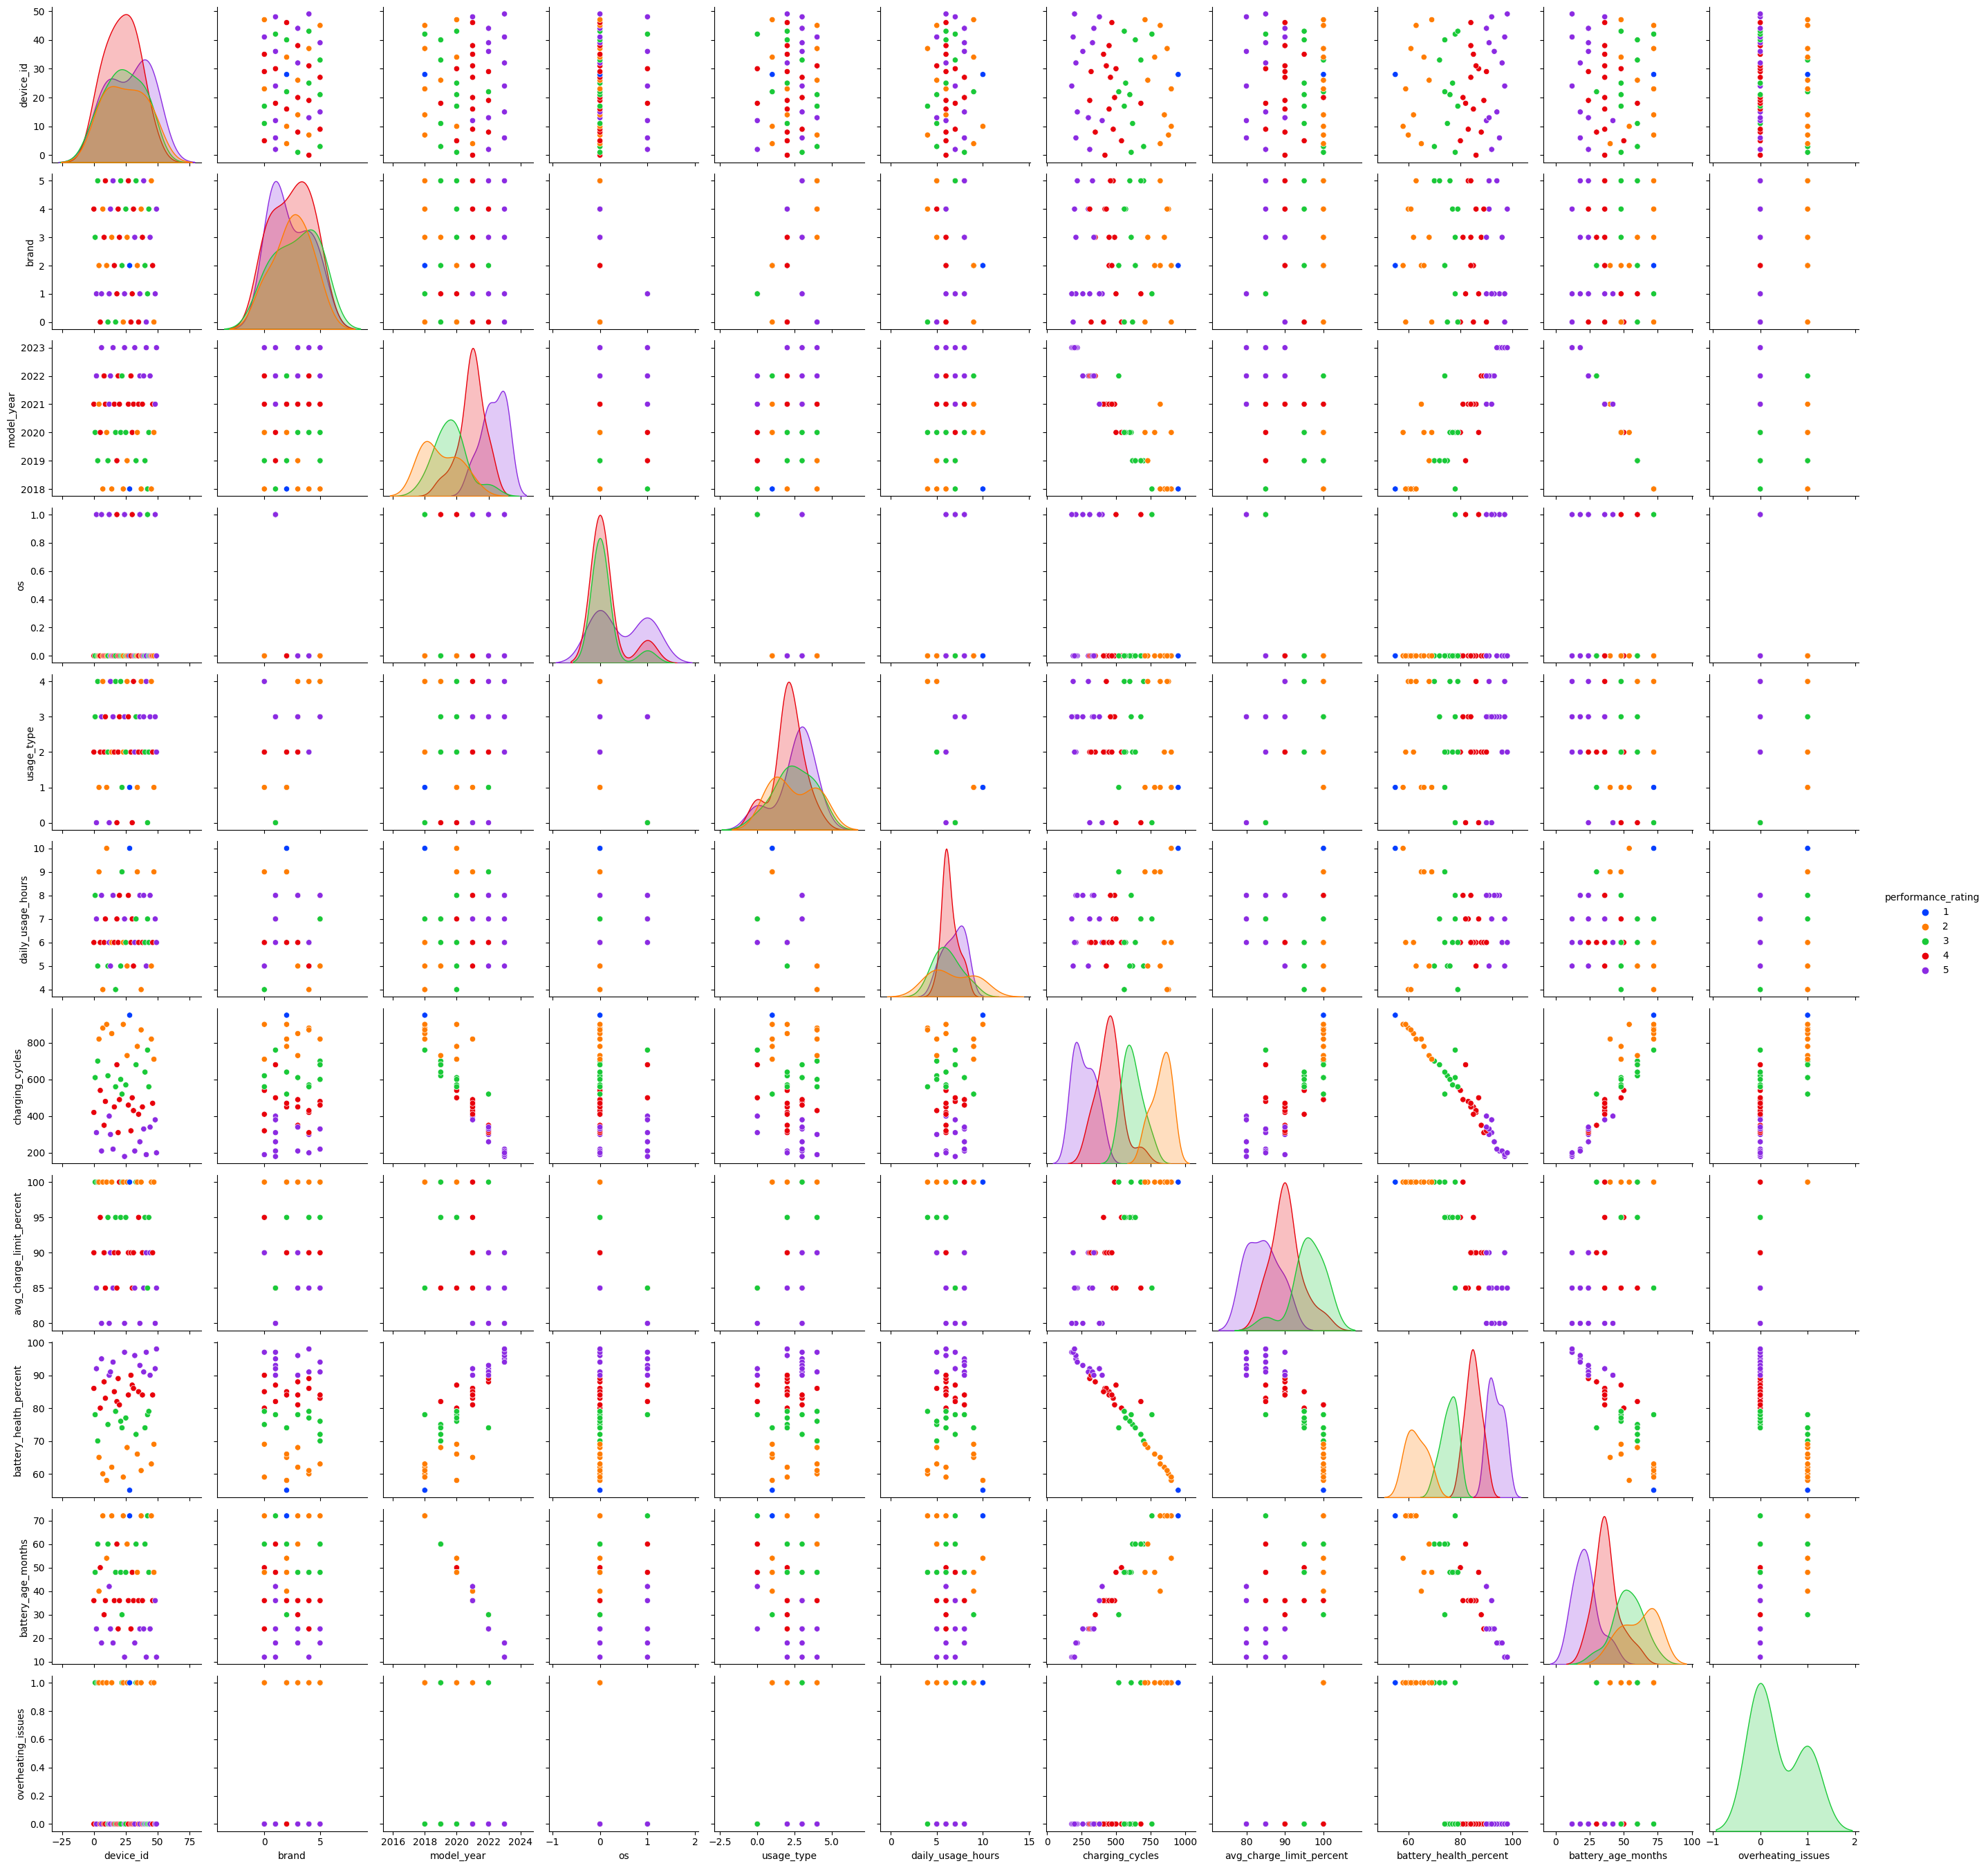

In [10]:
# Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# Pairplot for relationships
sns.pairplot(df, diag_kind='kde', hue='performance_rating', palette='bright')
plt.show()


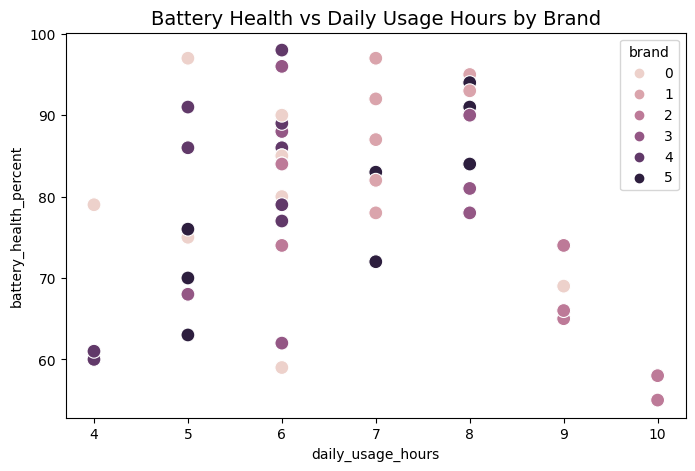

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='daily_usage_hours', y='battery_health_percent', hue='brand', s=100)
plt.title('Battery Health vs Daily Usage Hours by Brand', fontsize=14)
plt.show()


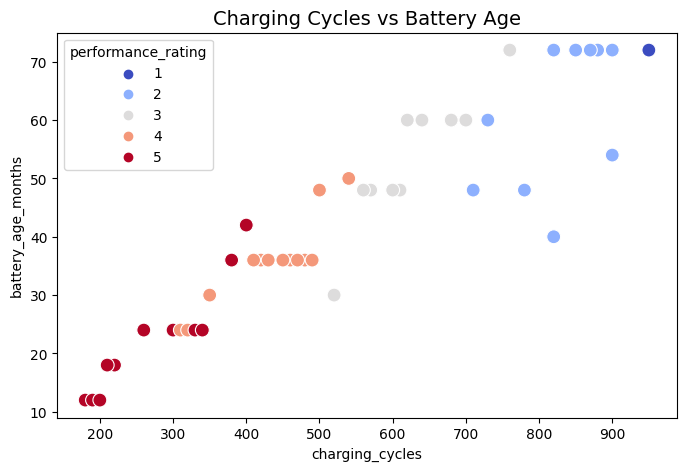

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='charging_cycles', y='battery_age_months', hue='performance_rating', s=100, palette='coolwarm')
plt.title('Charging Cycles vs Battery Age', fontsize=14)
plt.show()


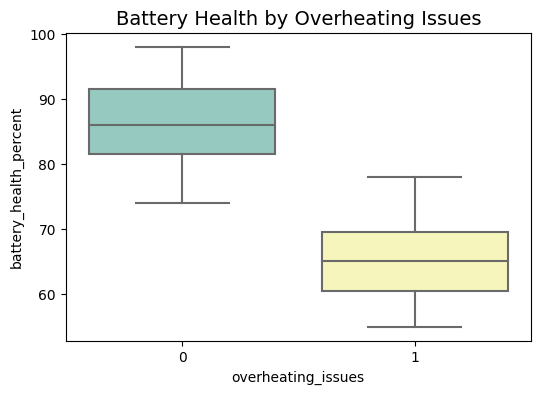

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='overheating_issues', y='battery_health_percent', data=df, palette='Set3')
plt.title('Battery Health by Overheating Issues', fontsize=14)
plt.show()


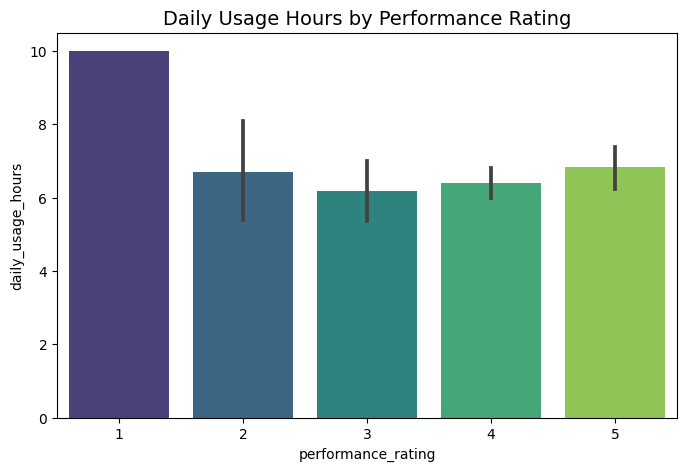

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='performance_rating', y='daily_usage_hours', data=df, palette='viridis')
plt.title('Daily Usage Hours by Performance Rating', fontsize=14)
plt.show()


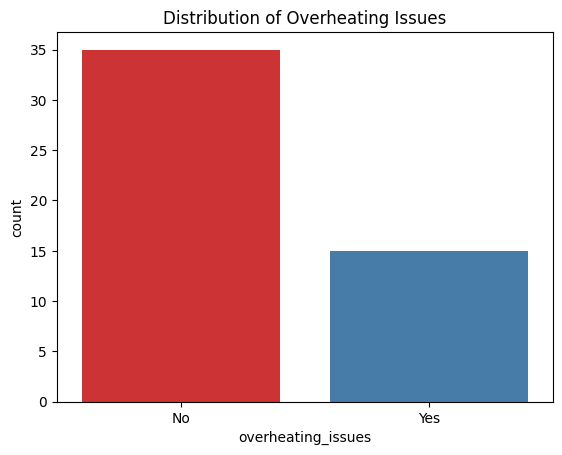

In [15]:
sns.countplot(x='overheating_issues', data=df, palette='Set1')
plt.title('Distribution of Overheating Issues')
plt.xticks([0,1], ['No','Yes'])
plt.show()


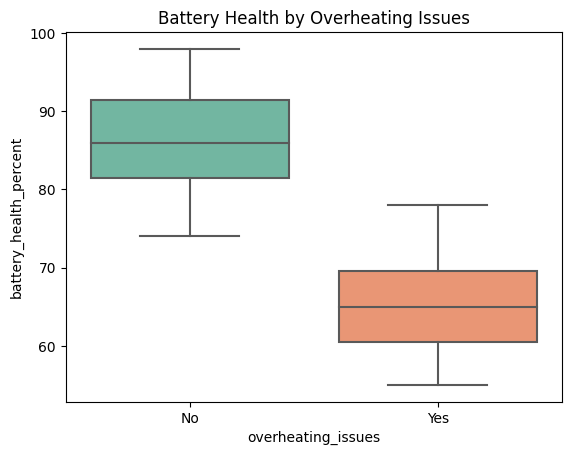

In [16]:
sns.boxplot(x='overheating_issues', y='battery_health_percent', data=df, palette='Set2')
plt.title('Battery Health by Overheating Issues')
plt.xticks([0,1], ['No','Yes'])
plt.show()


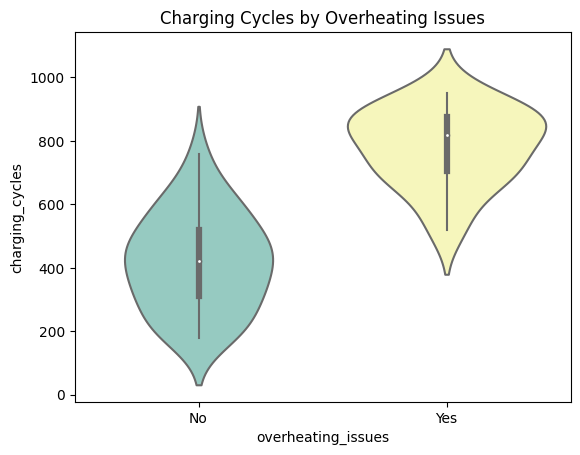

In [17]:
sns.violinplot(x='overheating_issues', y='charging_cycles', data=df, palette='Set3')
plt.title('Charging Cycles by Overheating Issues')
plt.xticks([0,1], ['No','Yes'])
plt.show()


In [18]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [19]:
X = df.drop(['device_id','overheating_issues'], axis=1)  # features
y = df['overheating_issues']  # target


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



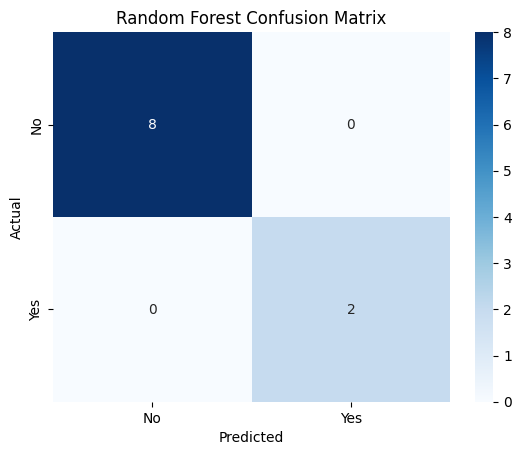

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


In [23]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 1.0


In [24]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 1.0


In [25]:
svc = SVC()
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svc))


SVM Accuracy: 1.0


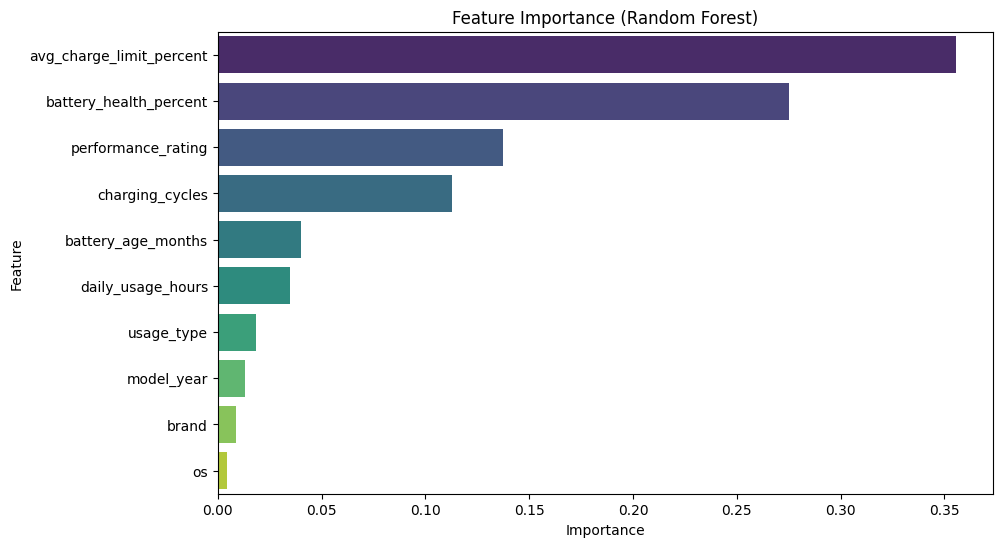

In [26]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()
